# part 1  Trading strategy

Description of my trading strategy

This strategy is entirely based on the "Intrinsic Time" framework, meaning it does not focus on the pass of real physical time, but only focuses on the occurrence of events. The core of this strategy lies in the belief that the OS (Overshoot) after a DC (Directional Change) occurs has momentum and will continue for a certain distance, and the strategy profits precisely during this period. 

This strategy can be broken down into entry rules and exit rules.

The entry rules are:For a long position: open a long position after an Upward DC occurs; For a short position: open a short position after a Downward DC occurs.  It should be noted that, at the time of entry, the strategy records the extreme price of the DC that triggered the entry, which is used for the subsequent calculation of the target price.

The exit rules are: a. Take profit: When the actual OS reaches the expectation (this strategy expects the OS to continue for the same $\theta$ as the DC); b. Stop Loss: Set a hard stop-loss line at a distance of $\theta/2$ in the opposite direction from the entry price; c. Trend Reversal: Close the position when the target price is not reached but a reverse DC is confirmed to have occurred.

Below is the pseudo Code of this strategy:

Input: 

    - Tick data with Mid-price (p)
  
    - Threshold (θ)
  
Variables: 

    - current_trend: 'up', 'down', or 'warmup'
  
    - ext_price: highest/lowest price in current trend
  
    - position: 0 (flat), 1 (long), -1 (short)
  
    - entry_p: execution price of trade
  
    - ext_r: extreme price of the DC that triggered the entry

For each new tick p:

    // Step 1: Dissect Intrinsic Time
    If current_trend is 'up':
        If p > ext_price: 
            ext_price = p
        Else If p <= ext_price * (1 - θ):
            current_trend = 'down'
            Trigger DC_Down
            ext_price = p
            
    Else If current_trend is 'down':
        If p < ext_price:
            ext_price = p
        Else If p >= ext_price * (1 + θ):
            current_trend = 'up'
            Trigger DC_Up
            ext_price = p

    // Step 2: Execute Trading Logic
    If position == 0:  // Looking for entry
        If DC_Up triggered:
            position = 1
            entry_p = p
            ext_r = ext_price (before reset)
        Else If DC_Down triggered:
            position = -1
            entry_p = p
            ext_r = ext_price (before reset)

    Else If position == 1:  // Long
        Target = ext_r * (1 + 2*θ)
        StopLoss = entry_p * (1 - θ/2)
        
        If p >= Target OR p <= StopLoss OR DC_Down triggered:
            position = 0  // Close long

    Else If position == -1: // Short
        Target = ext_r * (1 - 2*θ)
        StopLoss = entry_p * (1 + θ/2)
        
        If p <= Target OR p >= StopLoss OR DC_Up triggered:
            position = 0  // Close short

In [11]:
import pandas as pd
def load_and_clean_tick_data(file_path):
    df = pd.read_csv(file_path, 
                     header=None, 
                     names=['datetime', 'bid', 'ask', 'vol'])
    
    df['datetime'] = pd.to_datetime(df['datetime'], format='%Y%m%d %H%M%S%f') # %H%M%S%f represents hours, minutes, seconds, and microseconds in the datetime format
    df.set_index('datetime', inplace=True)
    
    df['mid_price'] = (df['bid'] + df['ask']) / 2
    
    df.drop(columns=['vol'], inplace=True)
    
    print("Data loaded and cleaned successfully.")
    return df

file_path_eurgbp = 'D:\\King\'s College London\\Semester2\\High Frequency Finance\\Coursework2\\HISTDATA_COM_ASCII_EURGBp_T201606\\DAT_ASCII_EURGBp_T_201606.csv' 
df_eurgbp = load_and_clean_tick_data(file_path_eurgbp)
display(df_eurgbp.head())

file_path_eurusd = 'D:\\King\'s College London\\Semester2\\High Frequency Finance\\Coursework2\\HISTDATA_COM_ASCII_EURUSD_T201912\\DAT_ASCII_EURUSD_T_201912.csv'
df_eurusd = load_and_clean_tick_data(file_path_eurusd)
display(df_eurusd.head())

Data loaded and cleaned successfully.


,bid,ask,mid_price
datetime,,,
2016-06-01 00:00:01.687,0.76777,0.76784,0.767805
2016-06-01 00:00:03.937,0.76777,0.76785,0.767810
2016-06-01 00:00:07.937,0.76776,0.76784,0.767800
2016-06-01 00:00:20.937,0.76778,0.76786,0.767820
2016-06-01 00:00:21.687,0.76777,0.76785,0.767810


Data loaded and cleaned successfully.


,bid,ask,mid_price
datetime,,,
2019-12-01 17:00:03.296,1.10229,1.10247,1.102380
2019-12-01 17:00:04.413,1.10232,1.10247,1.102395
2019-12-01 17:00:05.270,1.10229,1.10247,1.102380
2019-12-01 17:00:06.063,1.10228,1.10246,1.102370
2019-12-01 17:00:06.629,1.10226,1.10244,1.102350


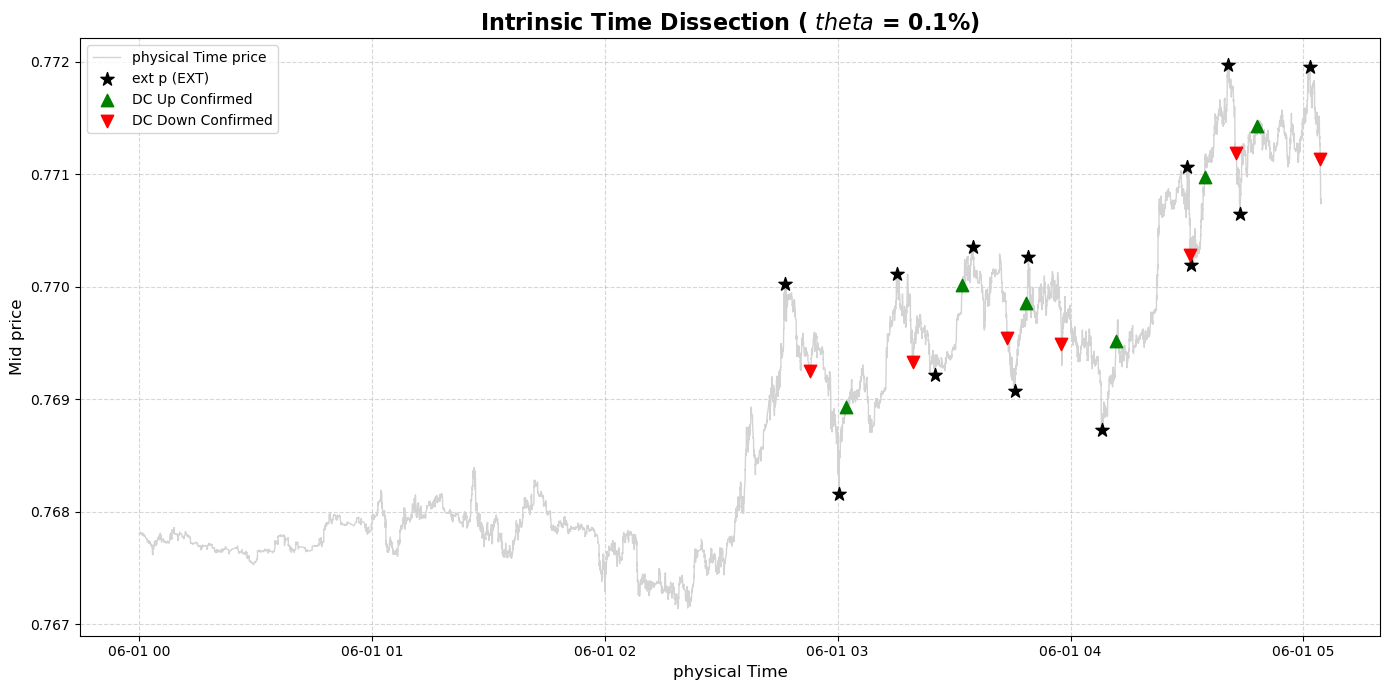

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_intrinsic_time_framework(df_subset, theta=0.001):
    
    ext_p = []
    dc_up_p = []
    dc_down_p = []
    
    trend = "warmup"
    ext_price = df_subset['mid_price'].iloc[0]
    ext_time = df_subset.index[0]  # also need to track the exact time of the ext
    
    for row in df_subset.itertuples():
        t = row.Index
        p = row.mid_price
        
        if trend == "warmup":  # We are just looking for the first EXT point to find a trend
            if p >= ext_price * (1 + theta):
                trend = "up"
                ext_price = p
                ext_time = t
            elif p <= ext_price * (1 - theta):
                trend = "down"
                ext_price = p
                ext_time = t
            continue
            
        if trend == "up": 
            if p > ext_price:
                ext_price = p
                ext_time = t
            elif p <= ext_price * (1 - theta):  # DC Down confirmed
                dc_down_p.append((t, p))
                ext_p.append((ext_time, ext_price))
                trend = "down"
                ext_price = p
                ext_time = t
                
        elif trend == "down":
            if p < ext_price:
                ext_price = p
                ext_time = t 
            elif p >= ext_price * (1 + theta):  # DC Up confirmed
                dc_up_p.append((t, p))
                ext_p.append((ext_time, ext_price))
                trend = "up"
                ext_price = p
                ext_time = t

    plt.figure(figsize=(14, 7))
    
    # pphysical time price curve
    plt.plot(df_subset.index, df_subset['mid_price'], color='lightgrey', label='physical Time price', linewidth=1)
    
    # ext p
    if ext_p:
        ext_x, ext_y = zip(*ext_p)
        plt.scatter(ext_x, ext_y, color='black', marker='*', s=100, label='ext p (EXT)', zorder=5)
        
    # Upward DC
    if dc_up_p:
        up_x, up_y = zip(*dc_up_p)
        plt.scatter(up_x, up_y, color='green', marker='^', s=80, label='DC Up Confirmed', zorder=5)
        
    # Downward DC
    if dc_down_p:
        down_x, down_y = zip(*dc_down_p)
        plt.scatter(down_x, down_y, color='red', marker='v', s=80, label='DC Down Confirmed', zorder=5)

    plt.title(f'Intrinsic Time Dissection ($\ theta$ = {theta*100}%)', fontsize=16, fontweight='bold')
    plt.xlabel('physical Time', fontsize=12)
    plt.ylabel('Mid price', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    # Show the plot
    plt.show()

sample_data = df_eurgbp.iloc[:20000] 
plot_intrinsic_time_framework(sample_data, theta=0.001)  # Use a larger theta to make the DC events clearly visible

In [13]:
import pandas as pd

def get_trend(p, trend, ext_p, theta):

    signal = "none"
    
    if trend == "up":
        if p > ext_p:
            ext_p = p 
        elif p <= ext_p * (1 - theta):
            trend = "down"
            ext_p = p
            signal = "dc_down"
            
    elif trend == "down":
        if p < ext_p:
            ext_p = p
        elif p >= ext_p * (1 + theta):
            trend = "up"
            ext_p = p
            signal = "dc_up"
            
    return trend, ext_p, signal

def strategy(signal, current_pos, p, entry_price, ext_r, theta):

    action = "hold"
    reason = "none"
    new_pos = current_pos

    # Look for entry
    if current_pos == 0:
        if signal == "dc_up":
            action = "open_long"
            reason = "dc_up_confirmed"
            new_pos = 1
        elif signal == "dc_down":
            action = "open_short"
            reason = "dc_down_confirmed"
            new_pos = -1

    # Look for exit if we are long
    elif current_pos == 1:
        target_price = ext_r * (1 + 2 * theta)
        stop_loss = entry_price * (1 - theta / 2)
        
        if p >= target_price:
            action = "close_long"
            reason = "hit_target_price"
            new_pos = 0
        elif p <= stop_loss:
            action = "close_long"
            reason = "hit_stop_loss"
            new_pos = 0
        elif signal == "dc_down":  # when trend reverses, even if we haven't hit the target or stop loss, we also exit
            action = "close_long"
            reason = "trend_reversed"
            new_pos = 0
            
    # Look for exit if we are short
    elif current_pos == -1:
        target_price = ext_r * (1 - 2 * theta)
        stop_loss = entry_price * (1 + theta / 2)
        
        if p <= target_price:
            action = "close_short"
            reason = "hit_target_price"
            new_pos = 0
        elif p >= stop_loss:
            action = "close_short"
            reason = "hit_stop_loss"
            new_pos = 0
        elif signal == "dc_up":
            action = "close_short"
            reason = "trend_reversed"
            new_pos = 0
            
    return action, reason, new_pos

def backtest(df, theta=0.0005):
   
    trade_history = []
    
    trend = "warmup"
    ext_price = df['mid_price'].iloc[0]
    
    pos = 0 
    entry_p = 0.0
    ext_r = 0.0
    
    for row in df.itertuples():
        t = row.Index
        price = row.mid_price
        
        if trend == "warmup":
            if price >= ext_price * (1 + theta):
                trend = "up"
                ext_price = price
            elif price <= ext_price * (1 - theta):
                trend = "down"
                ext_price = price
            continue
            
        old_ext = ext_price 
        
        trend, ext_price, dc_event = get_trend(price, trend, ext_price, theta)
        
        trade_action, trade_reason, updated_pos = strategy(
            dc_event, pos, price, entry_p, ext_r, theta
        )
        
        if trade_action != "hold":
            
            if "open" in trade_action:
                entry_p = price
                ext_r = old_ext
                
            trade_history.append({
                'Time': t,
                'Action': trade_action,
                'price': price,
                'Reason': trade_reason
            })
            pos = updated_pos
            
    return pd.DataFrame(trade_history)

result_eurgbp = backtest(df_eurgbp, theta=0.0005)
display(result_eurgbp.head(15))


,Time,Action,price,Reason
0,2016-06-01 01:03:34.207,open_short,0.767805,dc_down_confirmed
1,2016-06-01 01:08:13.190,close_short,0.767990,trend_reversed
2,2016-06-01 01:27:06.697,open_short,0.767995,dc_down_confirmed
3,2016-06-01 01:33:45.430,close_short,0.767620,hit_target_price
4,2016-06-01 01:38:49.177,open_long,0.767975,dc_up_confirmed
5,2016-06-01 01:46:09.690,close_long,0.767875,trend_reversed
6,2016-06-01 02:01:02.920,open_long,0.767675,dc_up_confirmed
7,2016-06-01 02:08:19.433,close_long,0.767470,hit_stop_loss
8,2016-06-01 02:08:23.933,open_short,0.767380,dc_down_confirmed
9,2016-06-01 02:23:04.453,close_short,0.767550,trend_reversed


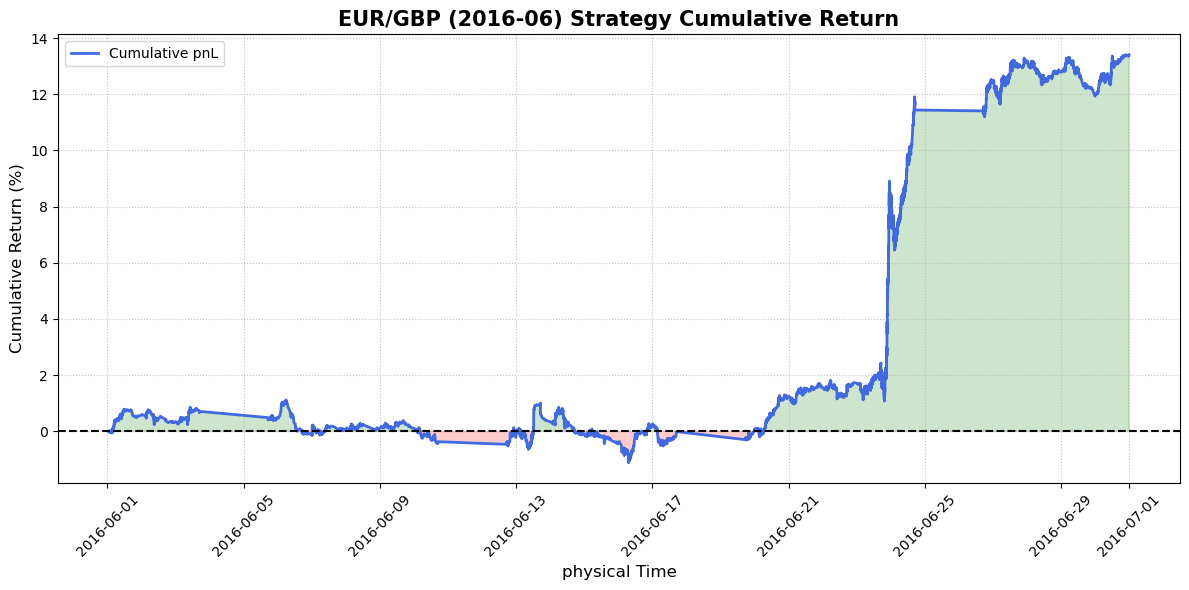

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_cumulative_return(trades_df, title="Strategy Cumulative Return"):
   
    times = []
    pnl_history = []
    
    current_cumulative_pnl = 0.0
    entry_p = 0.0
    current_pos = 0 
    
    for row in trades_df.itertuples():
        t = row.Time
        action = row.Action
        price = row.price
        
        if action == "open_long":
            entry_p = price
            current_pos = 1
            
        elif action == "open_short":
            entry_p = price
            current_pos = -1
            
        elif action == "close_long" and current_pos == 1:
            # For long, profit is (Exit - Entry) / Entry
            trade_ret = (price - entry_p) / entry_p
            current_cumulative_pnl += trade_ret
            
            times.append(t)
            pnl_history.append(current_cumulative_pnl * 100) # Convert to percentage
            current_pos = 0
            
        elif action == "close_short" and current_pos == -1:
            # For short, profit is (Entry - Exit) / Entry
            trade_ret = (entry_p - price) / entry_p
            current_cumulative_pnl += trade_ret
            
            times.append(t)
            pnl_history.append(current_cumulative_pnl * 100) # Convert to percentage
            current_pos = 0
            
    plt.figure(figsize=(12, 6))
    
    if len(times) > 0:
        plt.plot(times, pnl_history, color='royalblue', linewidth=2, label='Cumulative pnL')
        
        pnl_series = pd.Series(pnl_history)
        plt.fill_between(times, pnl_history, 0, where=(pnl_series >= 0), color='green', alpha=0.2)
        plt.fill_between(times, pnl_history, 0, where=(pnl_series < 0), color='red', alpha=0.2)
    else:
        print("No completed trades to plot.")
        return
        
    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel('physical Time', fontsize=12)
    plt.ylabel('Cumulative Return (%)', fontsize=12)
    plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    
    plt.show()

plot_cumulative_return(result_eurgbp, "EUR/GBP (2016-06) Strategy Cumulative Return")

# part 2 Backtest

,Time,Action,price,Reason
0,2019-12-01 20:29:54.409,open_long,1.102090,dc_up_confirmed
1,2019-12-01 20:55:33.865,close_long,1.101805,hit_stop_loss
2,2019-12-02 02:56:24.478,open_short,1.101725,dc_down_confirmed
3,2019-12-02 03:00:44.435,close_short,1.102005,hit_stop_loss
4,2019-12-02 04:31:56.304,open_long,1.101680,dc_up_confirmed
5,2019-12-02 04:41:07.001,close_long,1.101400,hit_stop_loss
6,2019-12-02 06:00:09.872,open_short,1.101155,dc_down_confirmed
7,2019-12-02 06:07:04.822,close_short,1.101435,hit_stop_loss
8,2019-12-02 07:32:02.479,open_long,1.100855,dc_up_confirmed
9,2019-12-02 07:49:48.055,close_long,1.101405,hit_target_price


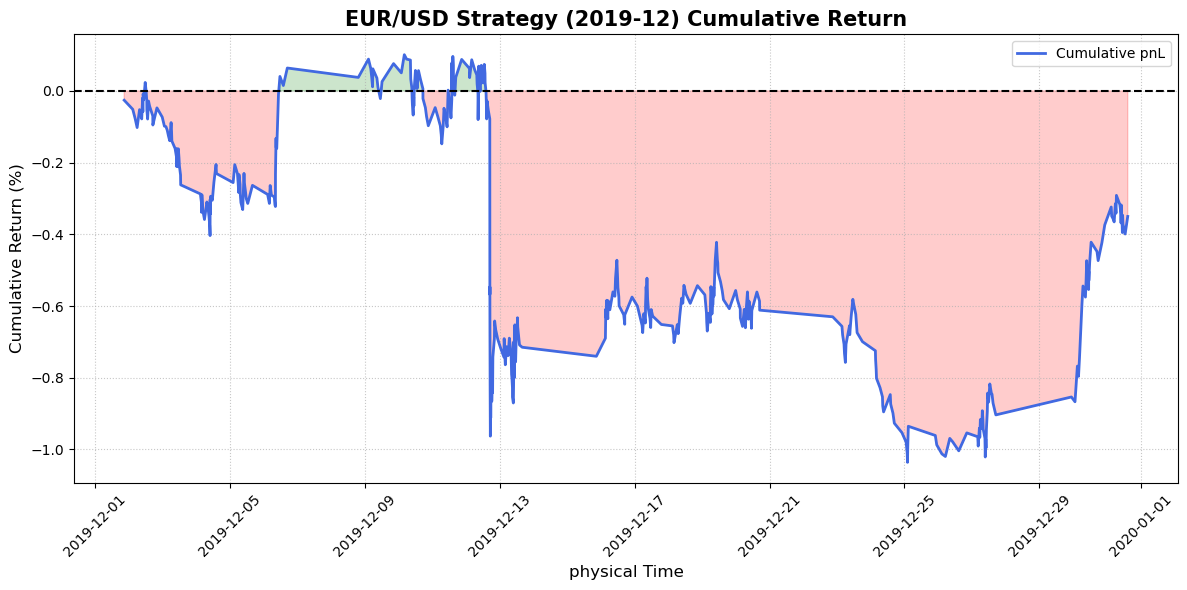

In [15]:
result_eurusd = backtest(df_eurusd, theta=0.0005)

display(result_eurusd.head(15))

plot_cumulative_return(result_eurusd, "EUR/USD Strategy (2019-12) Cumulative Return")

Reflecting on the results of the backtest

The empirical data of this study comes from the EUR/GBP exchange rate in June 2016 and the EUR/USD exchange rate in December 2019. The $\theta$ value used in the empirical study is 0.0005 (0.05%). Through the cumulative return chart, it can be seen that the strategy used this time performed well in the trading of EUR/GBP in June 2016, but its trading performance in EUR/USD in December 2019 was not very satisfactory. Next, I will analyze them one by one.

First, let's look at EUR/GBP in June 2016. Before June 23rd, the return rate fluctuated between -1% and 2%, and suddenly rose sharply after the 23rd, with the maximum return rate reaching around 13%. Through inquiry, it is known that this period was exactly the Brexit referendum, and on June 24th, the UK voted to leave the European Union. Precisely because of this unexpected voting result, the British pound suffered panic selling, and the exchange rate of the pound against all currencies was falling. This exactly benefits our strategy, because the strategy used this time is very suitable for long trends in the same direction, and can perfectly reach our preset target price multiple times, thus resulting in a good return rate.

In contrast, for EUR/USD in December 2019, there were only a few short periods with a positive return rate, and the return rate for most periods was negative, with the lowest being around -1%. Although there was a macro event in mid-December 2019 where China and the US officially announced the reaching of the "Phase One Deal", its impact on EUR/USD was small, so December can be seen as an ordinary trading month without the influence of major macro events. In an ordinary trading month, because the strategy this time sets the take-profit point at a distance of $2\theta$ from the entry extreme point, however, in ordinary trading days, most trades may not be able to trigger the take-profit point, and they turn around before touching it, thereby triggering the strategy's position closing, which causes the strategy to perform poorly under this dataset.

To solve this problem, I think some other exit indicators should be added to the purely price-driven strategy, rather than stubbornly waiting for the price to reach the setting, regardless of how long the market is stalled in a sideways trend. I think a time indicator can be introduced; while recording the extreme price that triggers the DC and enters the market, also record the time required for this one $\theta$ to occur, and subsequently stipulate a maximum trading time window, for example, equal to the time required for one $\theta$ to occur. In this way, the risk exposure can be cut off in a timely manner in a stagnant market like EUR/USD, while preserving the ability to capture rapid trend extensions during high-volatility events like Brexit.